# Comparação: texto completo, prefixo e todos os trechos

Notebook autossuficiente para Colab, derivado dos experimentos anteriores.
As seções 1–17 reexecutam os controles de texto completo e primeiros 300 caracteres
com seis features recalculáveis. **O novo experimento e sua conclusão estão nas
seções 18–20:** todo o texto é dividido em janelas de 300 caracteres sem sobreposição.

No treino, sorteamos um trecho por notícia True, com probabilidade proporcional
ao tamanho do trecho e semente 42: cada notícia fornece exatamente um exemplo.
Na validação/teste, todas as janelas são pontuadas. O score da notícia é a média
dos scores ponderada pelo número de caracteres de cada trecho. O corte é o
percentil 95 dos scores agregados das 720 True de validação.

Mantemos os mesmos IDs/split por notícia, 300 árvores, seis features e presença
de autor. num_palavras permanece na extração, fora da matriz de treinamento.
Nenhuma Fake entra em fit/calibração. Não selecionamos agregação pelo teste.

Esta mudança altera a amostragem do treino e a agregação; não isola apenas o
efeito de tamanho. A média pode diluir uma alegação anômala localizada, e o treino
não utiliza todas as janelas. Caracteres fixos não garantem independência de palavras.

**Colab:** Arquivo → Abrir notebook → Upload, envie somente este `.ipynb` e
Execute tudo em CPU. O ZIP do Fake.br é baixado automaticamente se não estiver
no cache `data/`. Não depende de outros notebooks, scripts locais ou news-analysis.
O notebook foi validado localmente; a interface hospedada do Colab não foi testada.


## 2. Imports

Semente fixa de 42. As versões do ambiente ficam registradas para reprodução.

In [1]:
from pathlib import Path
from urllib.request import urlopen
from zipfile import ZipFile
from itertools import combinations
from importlib.metadata import version
import hashlib
import platform

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from sklearn.ensemble import IsolationForest
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, average_precision_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_curve, precision_recall_curve,
    ConfusionMatrixDisplay,
)

In [2]:
RANDOM_STATE = 42
pd.set_option("display.max_rows", 80)
pd.set_option("display.max_columns", 20)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.2})
print("Python:", platform.python_version())
print({name: version(name) for name in ["numpy", "pandas", "scikit-learn", "matplotlib", "ipykernel"]})

Python: 3.12.10
{'numpy': '2.5.3', 'pandas': '3.0.5', 'scikit-learn': '1.9.0', 'matplotlib': '3.11.1', 'ipykernel': '7.3.0'}


## 3. Carregamento dos dados

Mesmo ZIP e revisão fixa do notebook original. Textos completos e metadados são
carregados para auditoria; o truncamento acontece ANTES da extração usada nos
modelos. Nenhuma notícia é excluída por comprimento.

In [3]:
CORPUS_REVISION = "780f5516c4ae070761632d98ac3368f3ded09d35"
CORPUS_URL = f"https://codeload.github.com/roneysco/Fake.br-Corpus/zip/{CORPUS_REVISION}"
projectFolder = Path.cwd()
dataFolder = projectFolder / "data"
dataFolder.mkdir(exist_ok=True)
archivePath = dataFolder / f"Fake.br-Corpus-{CORPUS_REVISION}.zip"

if not archivePath.exists():
    temporaryPath = archivePath.with_suffix(".download")
    with urlopen(CORPUS_URL, timeout=120) as response, temporaryPath.open("wb") as target:
        while chunk := response.read(1024 * 1024):
            target.write(chunk)
    with ZipFile(temporaryPath) as archive:
        assert archive.testzip() is None, "ZIP corrompido; refaça o download."
    temporaryPath.replace(archivePath)

print("Corpus revision:", CORPUS_REVISION)
print("Archive SHA256:", hashlib.sha256(archivePath.read_bytes()).hexdigest())

Corpus revision: 780f5516c4ae070761632d98ac3368f3ded09d35
Archive SHA256: be91c188f621424017bd79a0f33528dcc27f8a6151adb2bcb899c17719eb4090


In [4]:
metadataColumns = [
    "autor", "link", "categoria", "data_publicacao",
    "num_tokens", "num_palavras", "num_types", "num_links", "num_maiusculas",
    "num_verbos", "num_verbos_subj_imp", "num_substantivos", "num_adjetivos",
    "num_adverbios", "num_verbos_modais", "num_pron_1_2_sing", "num_pron_1_plural",
    "num_pronomes", "pausalidade", "num_caracteres", "tam_medio_sentenca",
    "tam_medio_palavra", "pct_erros_ortograficos", "emotividade", "diversidade",
]

In [5]:
def loadNewsTexts(archive, folder, label):
    records = []
    for name in sorted(archive.namelist()):
        if f"/full_texts/{folder}/" not in name or not name.endswith(".txt"):
            continue
        articleId = Path(name).stem + ("t" if label == 0 else "")
        records.append({
            "id": articleId, "text": archive.read(name).decode("utf-8"),
            "label": label, "sourceClass": folder,
        })
    assert records, f"Nenhum texto encontrado em {folder}"
    return pd.DataFrame(records)


def loadNewsMetadata(archive, folder, label):
    records = []
    for name in sorted(archive.namelist()):
        if f"/full_texts/{folder}-meta-information/" not in name or not name.endswith("-meta.txt"):
            continue
        values = [line.strip() for line in archive.read(name).decode("utf-8").splitlines()]
        assert len(values) == len(metadataColumns), f"Esquema inesperado em {name}: {len(values)} linhas"
        articleId = Path(name).name.removesuffix("-meta.txt") + ("t" if label == 0 else "")
        records.append({**dict(zip(metadataColumns, values)), "id": articleId, "metadataLabel": label})
    assert records, f"Nenhum metadado encontrado em {folder}"
    return pd.DataFrame(records)

In [6]:
with ZipFile(archivePath) as archive:
    textsFrame = pd.concat([
        loadNewsTexts(archive, "fake", 1), loadNewsTexts(archive, "true", 0),
    ], ignore_index=True)
    metadataFrame = pd.concat([
        loadNewsMetadata(archive, "fake", 1), loadNewsMetadata(archive, "true", 0),
    ], ignore_index=True)

assert textsFrame["id"].is_unique and metadataFrame["id"].is_unique
assert set(textsFrame["id"]) == set(metadataFrame["id"]), "Texto/metadados sem correspondência"
newsFrame = textsFrame.merge(metadataFrame, on="id", validate="one_to_one", indicator=True)
assert newsFrame["_merge"].eq("both").all()
assert newsFrame["label"].eq(newsFrame["metadataLabel"]).all()
newsFrame = newsFrame.drop(columns=["_merge", "metadataLabel"])
assert newsFrame["text"].str.strip().ne("").all()
print(f"{len(newsFrame):,} notícias carregadas; textos e metadados correspondem 1:1.")

7,200 notícias carregadas; textos e metadados correspondem 1:1.


## 4. Contrato dos labels

**0 = True; 1 = Fake.** O rótulo forma as partições e permite avaliação externa.
Não entra como feature. A origem nas pastas também é verificada.

In [7]:
labelNames = {0: "True", 1: "Fake"}
assert labelNames == {0: "True", 1: "Fake"}
assert set(newsFrame["label"].unique()) == {0, 1}
assert newsFrame.loc[newsFrame["label"].eq(0), "sourceClass"].eq("true").all()
assert newsFrame.loc[newsFrame["label"].eq(1), "sourceClass"].eq("fake").all()
display(newsFrame.groupby(["label", "sourceClass"]).size().rename("newsCount").to_frame())

,,newsCount
label,sourceClass,
0,true,3600
1,fake,3600


## 5. Preparação dos metadados

Preservamos todos os campos brutos em `rawNewsFrame` e todas as contagens numéricas
em `newsFrame`. Valores não numéricos viram NaN com contagem explícita; nenhum
ausente é preenchido antes do treino. `tem_autor` segue a lógica do original:
ausência para string vazia, `None`, `none` ou `NULL`. Não é uma medida de credibilidade.

In [8]:
rawNewsFrame = newsFrame.copy(deep=True)
numericMetadataColumns = metadataColumns[4:]
convertedMetadata = newsFrame[numericMetadataColumns].apply(pd.to_numeric, errors="coerce")
conversionMissing = convertedMetadata.isna().sum().rename("missingAfterNumericConversion")
display(conversionMissing.to_frame())
newsFrame[numericMetadataColumns] = convertedMetadata
newsFrame["tem_autor"] = (~newsFrame["autor"].fillna("").astype(str).str.strip().isin(
    ["", "None", "none", "NULL"]
)).astype(int)

,missingAfterNumericConversion
num_tokens,0
num_palavras,0
num_types,0
num_links,1393
num_maiusculas,0
num_verbos,0
num_verbos_subj_imp,0
num_substantivos,0
num_adjetivos,0
num_adverbios,0


## 6. Extração no texto efetivamente utilizado

Normalização Unicode NFKC, remoção do BOM inicial e primeiros CHARACTER_LIMIT
caracteres, incluindo espaços/pontuação. Textos menores permanecem menores, sem
preenchimento. O corte pode dividir palavras/frases. Palavras são sequências de
letras com hífen/apóstrofo interno; tokens também incluem números e pontuação.
Tipos são palavras distintas ignorando caixa. TTR = tipos/tokens; diversidade =
tipos/palavras. Maiúsculas conta palavras totalmente maiúsculas com mais de uma
letra. Links são URLs http(s) presentes no corpo. Estas definições explícitas
não pretendem reproduzir o extrator desconhecido dos metadados históricos.

As demais contagens linguísticas são marcadas ausentes na cópia de features,
não imputadas nem selecionadas pelo modelo; originais ficam em rawNewsFrame e
newsFrame. Autor permanece como metadado válido da notícia inteira.

In [9]:
def calculateRatio(numerator, denominator):
    numerator = pd.to_numeric(numerator, errors="coerce").astype(float)
    denominator = pd.to_numeric(denominator, errors="coerce").astype(float)
    safeDenominator = denominator.where(denominator.gt(0) & np.isfinite(denominator))
    return numerator.div(safeDenominator).replace([np.inf, -np.inf], np.nan)

In [10]:
import re
import unicodedata

CHARACTER_LIMIT = 300
numericMetadataColumns = metadataColumns[4:]
anomalyColumns = ["tem_autor", "typeTokenRatio", "linkDensity", "punctuationDensity", "uppercaseRatio", "diversidade"]
wordPattern = re.compile(r"[^\W\d_]+(?:['’\-][^\W\d_]+)*", re.UNICODE)
tokenPattern = re.compile(r"[^\W\d_]+(?:['’\-][^\W\d_]+)*|\d+(?:[.,]\d+)*|[^\w\s]", re.UNICODE)


def measureText(text, characterLimit):
    normalized = unicodedata.normalize("NFKC", text).lstrip("\ufeff")
    if characterLimit is not None:
        if not isinstance(characterLimit, int) or characterLimit < 1:
            raise ValueError("Limite deve ser inteiro positivo ou None.")
        normalized = normalized[:characterLimit]
    words = wordPattern.findall(normalized)
    return {"text": normalized, "num_palavras": len(words),
            "num_tokens": len(tokenPattern.findall(normalized)),
            "num_types": len({word.casefold() for word in words}),
            "num_links": len(re.findall(r"https?://\S+", normalized, flags=re.IGNORECASE)),
            "num_maiusculas": sum(word.isupper() and len(word) > 1 for word in words),
            "num_caracteres": len(normalized)}


def extractAnomalyFeatures(newsFrame, characterLimit=CHARACTER_LIMIT):
    featuresFrame = newsFrame.copy(deep=True)
    featuresFrame["num_palavras_original"] = newsFrame["num_palavras"]
    featuresFrame["text_original"] = newsFrame["text"]
    featuresFrame[numericMetadataColumns] = np.nan
    measurements = pd.DataFrame([measureText(text, characterLimit) for text in newsFrame["text"]], index=newsFrame.index)
    for column in measurements:
        featuresFrame[column] = measurements[column]
    featuresFrame["typeTokenRatio"] = calculateRatio(featuresFrame["num_types"], featuresFrame["num_tokens"])
    featuresFrame["diversidade"] = calculateRatio(featuresFrame["num_types"], featuresFrame["num_palavras"])
    featuresFrame["linkDensity"] = calculateRatio(featuresFrame["num_links"], featuresFrame["num_palavras"])
    featuresFrame["punctuationDensity"] = calculateRatio(featuresFrame["num_tokens"] - featuresFrame["num_palavras"], featuresFrame["num_tokens"])
    featuresFrame["uppercaseRatio"] = calculateRatio(featuresFrame["num_maiusculas"], featuresFrame["num_palavras"])
    return featuresFrame

In [11]:
featuresFrame = extractAnomalyFeatures(newsFrame)
featuresFrame[anomalyColumns] = featuresFrame[anomalyColumns].replace([np.inf, -np.inf], np.nan)
display(featuresFrame[anomalyColumns].isna().sum().rename("missingCount").to_frame())
print("Limite de caracteres:", CHARACTER_LIMIT)
display(featuresFrame.groupby("label")[["num_palavras_original", "num_palavras", "num_caracteres"]].agg(["min", "median", "max"]))
print("Textos menores que o limite:", int(featuresFrame["num_caracteres"].lt(CHARACTER_LIMIT).sum()))

,missingCount
tem_autor,0
typeTokenRatio,0
linkDensity,0
punctuationDensity,0
uppercaseRatio,0
diversidade,0


Limite de caracteres: 300


num_palavras_original              num_palavras             \
                        min median   max          min median max   
label                                                              
0                        20  922.0  7588           19   47.0  60   
1                         9  157.0  2294            8   48.0  64   

      num_caracteres              
                 min median  max  
label                             
0                114  300.0  300  
1                 46  300.0  300

Textos menores que o limite: 99


## 7. Sanity checks

As seis features utilizam o prefixo; a presença de autor vem dos metadados.
Contagens originais ficam preservadas para auditoria e não alimentam o modelo.

In [12]:
assert "num_palavras" not in anomalyColumns
assert "label" not in anomalyColumns and "id" not in anomalyColumns
assert len(anomalyColumns) == len(set(anomalyColumns)) == 6
assert featuresFrame["id"].is_unique
assert featuresFrame["num_caracteres"].le(CHARACTER_LIMIT).all()
assert featuresFrame["num_palavras_original"].equals(newsFrame["num_palavras"])
assert featuresFrame["num_verbos"].isna().all()
assert not np.isinf(featuresFrame[anomalyColumns].to_numpy(dtype=float)).any()
assert measureText("casa " * 100, 300)["num_palavras"] == 60
assert measureText("casa " * 100, 300)["num_caracteres"] == 300
print("Contagens do prefixo verificadas; num_palavras não entra no treinamento.")

Contagens do prefixo verificadas; num_palavras não entra no treinamento.


## 8. Análise estatística

Estatísticas descritivas por label, sem substituir vetores individuais por médias.
Esta inspeção do corpus completo atende ao protocolo exploratório: não usamos
seus resultados para selecionar features, ajustar hiperparâmetros ou threshold.
Qualquer escolha futura guiada por estes resultados exige nova avaliação independente.
Correlações de Pearson com comprimento são mostradas no total e por classe para
evitar confundir efeitos de classe e de tamanho. NaN em correlação pode indicar
feature constante. Mantemos as seis features recalculadas, inclusive possíveis redundâncias.

In [13]:
statisticsRecords = []
for label, group in featuresFrame.groupby("label", sort=True):
    for feature in anomalyColumns:
        values = group[feature]
        q1, q3 = values.quantile([0.25, 0.75])
        statisticsRecords.append({
            "label": label, "class": labelNames[label], "feature": feature,
            "count": values.count(), "mean": values.mean(), "median": values.median(),
            "std": values.std(), "min": values.min(), "Q1": q1, "Q3": q3,
            "IQR": q3 - q1, "max": values.max(), "missingCount": values.isna().sum(),
        })
featureStatistics = pd.DataFrame(statisticsRecords).set_index(["label", "class", "feature"])
display(featureStatistics)

lengthColumns = ["num_palavras", "num_tokens"]
lengthCorrelations = pd.concat({
    name: group[anomalyColumns + lengthColumns].corr().loc[anomalyColumns, lengthColumns]
    for name, group in [
        ("All", featuresFrame),
        ("True (0)", featuresFrame.loc[featuresFrame["label"].eq(0)]),
        ("Fake (1)", featuresFrame.loc[featuresFrame["label"].eq(1)]),
    ]
}, names=["group", "feature"])
display(lengthCorrelations)
featureCorrelations = featuresFrame[anomalyColumns].corr()
display(featureCorrelations.round(3))
display(lengthCorrelations.xs("typeTokenRatio", level="feature"))
print("Pearson TTR vs diversidade:", featureCorrelations.loc["typeTokenRatio", "diversidade"])

count      mean    median       std       min  \
label class feature                                                             
0     True  tem_autor            3600  0.979722  1.000000  0.140968  0.000000   
            typeTokenRatio       3600  0.698048  0.701754  0.068560  0.358974   
            linkDensity          3600  0.000000  0.000000  0.000000  0.000000   
            punctuationDensity   3600  0.145714  0.142857  0.048265  0.000000   
            uppercaseRatio       3600  0.019995  0.020000  0.023448  0.000000   
            diversidade          3600  0.817017  0.822222  0.065109  0.551020   
1     Fake  tem_autor            3600  0.020000  0.000000  0.140019  0.000000   
            typeTokenRatio       3600  0.664573  0.666667  0.066960  0.413333   
            linkDensity          3600  0.000000  0.000000  0.000000  0.000000   
            punctuationDensity   3600  0.167808  0.166667  0.056673  0.035714   
            uppercaseRatio       3600  0.022792  0.019608  0.032375  0.000000   
            diversidade          3600  0.799228  0.800000  0.067613  0.545455   

                                      Q1        Q3       IQR       max  \
label class feature                                                      
0     True  tem_autor           1.000000  1.000000  0.000000  1.000000   
            typeTokenRatio      0.655172  0.745455  0.090282  0.921569   
            linkDensity         0.000000  0.000000  0.000000  0.000000   
            punctuationDensity  0.111111  0.175439  0.064327  0.384615   
            uppercaseRatio      0.000000  0.025000  0.025000  0.315789   
            diversidade         0.777778  0.862745  0.084967  1.000000   
1     Fake  tem_autor           0.000000  0.000000  0.000000  1.000000   
            typeTokenRatio      0.621212  0.707095  0.085883  0.900000   
            linkDensity         0.000000  0.000000  0.000000  0.000000   
            punctuationDensity  0.127273  0.203390  0.076117  0.470588   
            uppercaseRatio      0.000000  0.039216  0.039216  0.420000   
            diversidade         0.755102  0.844444  0.089342  1.000000   

                                missingCount  
label class feature                           
0     True  tem_autor                      0  
            typeTokenRatio                 0  
            linkDensity                    0  
            punctuationDensity             0  
            uppercaseRatio                 0  
            diversidade                    0  
1     Fake  tem_autor                      0  
            typeTokenRatio                 0  
            linkDensity                    0  
            punctuationDensity             0  
            uppercaseRatio                 0  
            diversidade                    0

num_palavras  num_tokens
group    feature                                     
All      tem_autor              -0.016428   -0.158099
         typeTokenRatio         -0.107702   -0.485101
         linkDensity                  NaN         NaN
         punctuationDensity     -0.234614    0.436514
         uppercaseRatio         -0.029622    0.019670
         diversidade            -0.323344   -0.273850
True (0) tem_autor               0.023761    0.025026
         typeTokenRatio         -0.068439   -0.500045
         linkDensity                  NaN         NaN
         punctuationDensity     -0.241752    0.528841
         uppercaseRatio         -0.064469    0.010045
         diversidade            -0.255571   -0.245689
Fake (1) tem_autor               0.019447   -0.078203
         typeTokenRatio         -0.133990   -0.463896
         linkDensity                  NaN         NaN
         punctuationDensity     -0.249768    0.362342
         uppercaseRatio         -0.015290    0.013255
         diversidade            -0.375238   -0.274395

,tem_autor,typeTokenRatio,linkDensity,punctuationDensity,uppercaseRatio,diversidade
tem_autor,1.000,0.245,NaN,-0.221,-0.057,0.128
typeTokenRatio,0.245,1.000,NaN,-0.594,-0.088,0.780
linkDensity,NaN,NaN,NaN,NaN,NaN,NaN
punctuationDensity,-0.221,-0.594,NaN,1.000,0.073,0.036
uppercaseRatio,-0.057,-0.088,NaN,0.073,1.000,-0.051
diversidade,0.128,0.780,NaN,0.036,-0.051,1.000


,num_palavras,num_tokens
group,,
All,-0.107702,-0.485101
True (0),-0.068439,-0.500045
Fake (1),-0.133990,-0.463896


Pearson TTR vs diversidade: 0.7802288746199308


## 9. Train / Validation / Test

True: 60% treino, 20% validação, 20% teste. Fake: 50% validação, 50% teste.
Todas as divisões usam `random_state=42`. Verificamos IDs exclusivos e cobertura
integral do corpus. **Nenhuma notícia Fake participa de fit ou calibração.**

Limitação do protocolo solicitado: a divisão é por notícia, não por assunto,
fonte ou data. O corpus possui pares True/Fake com o mesmo número-base; IDs
`123t` e `123` são notícias distintas, mas podem tratar do mesmo assunto em
partições diferentes. IDs exclusivos não demonstram independência temática.

In [14]:
normalFrame = featuresFrame.loc[featuresFrame["label"].eq(0)].copy()
fakeFrame = featuresFrame.loc[featuresFrame["label"].eq(1)].copy()
normalTrainFrame, normalHoldoutFrame = train_test_split(
    normalFrame, train_size=0.60, random_state=RANDOM_STATE,
)
normalValidationFrame, normalTestFrame = train_test_split(
    normalHoldoutFrame, test_size=0.50, random_state=RANDOM_STATE,
)
fakeValidationFrame, fakeTestFrame = train_test_split(
    fakeFrame, test_size=0.50, random_state=RANDOM_STATE,
)
partitions = {
    "normalTrain": normalTrainFrame, "normalValidation": normalValidationFrame,
    "normalTest": normalTestFrame, "fakeValidation": fakeValidationFrame,
    "fakeTest": fakeTestFrame,
}
for name, frame in partitions.items():
    assert not frame.empty and frame["id"].is_unique
    assert frame["label"].eq(0 if name.startswith("normal") else 1).all()
for (leftName, left), (rightName, right) in combinations(partitions.items(), 2):
    assert set(left["id"]).isdisjoint(right["id"]), f"IDs compartilhados: {leftName}/{rightName}"
assert set().union(*(set(frame["id"]) for frame in partitions.values())) == set(featuresFrame["id"])
assert sum(len(frame) for frame in partitions.values()) == len(featuresFrame)
assert normalTrainFrame["label"].eq(0).all()
display(pd.DataFrame([
    {"partition": name, "count": len(frame), "label": int(frame["label"].iloc[0])}
    for name, frame in partitions.items()
]).set_index("partition"))

,count,label
partition,,
normalTrain,2160,0
normalValidation,720,0
normalTest,720,0
fakeValidation,1800,1
fakeTest,1800,1


## 10. Isolation Forest

Pipeline fixo: imputação pela mediana + 300 árvores, sem StandardScaler.
O único `.fit()` recebe exclusivamente `normalTrain`. Uma guarda rejeita Fake,
infinitos e features inteiramente ausentes no treino (evita remoção silenciosa
de colunas pelo imputer). Nem médias do corpus nem dados de validação/teste
participam do ajuste.

In [15]:
def fitNormalOnly(pipeline, trainingFrame):
    if trainingFrame.empty or not trainingFrame["label"].eq(0).all():
        raise ValueError("Treino permitido apenas com notícias True (label == 0).")
    trainingFeatures = trainingFrame[anomalyColumns]
    if np.isinf(trainingFeatures.to_numpy(dtype=float)).any():
        raise ValueError("Features de treino contêm infinito.")
    emptyColumns = trainingFeatures.columns[trainingFeatures.isna().all()].tolist()
    if emptyColumns:
        raise ValueError(f"Features inteiramente ausentes em normalTrain: {emptyColumns}")
    return pipeline.fit(trainingFeatures)

In [16]:
anomalyPipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("detector", IsolationForest(
        n_estimators=300, contamination="auto", random_state=42, n_jobs=-1,
    )),
])
fitNormalOnly(anomalyPipeline, normalTrainFrame)
assert list(anomalyPipeline.feature_names_in_) == anomalyColumns
assert anomalyPipeline["detector"].n_features_in_ == len(anomalyColumns)
np.testing.assert_allclose(
    anomalyPipeline["imputer"].statistics_, normalTrainFrame[anomalyColumns].median().to_numpy(),
)
print(f"Pipeline ajustado em {len(normalTrainFrame)} notícias True e 0 Fake.")
display(pd.Series(anomalyPipeline["imputer"].statistics_, index=anomalyColumns, name="normalTrainMedian").to_frame())

Pipeline ajustado em 2160 notícias True e 0 Fake.


,normalTrainMedian
tem_autor,1.000000
typeTokenRatio,0.700000
linkDensity,0.000000
punctuationDensity,0.142857
uppercaseRatio,0.020000
diversidade,0.820000


## 11. Anomaly scores

Invertemos `decision_function`: score menor = mais normal; maior = mais anômalo.
Scores podem ser negativos. Não são probabilidades e não são convertidos em
percentuais de falsidade. Fake validation é reservada para inspeção visual.

In [17]:
def calculateAnomalyScore(pipeline, featuresFrame):
    return -pipeline.decision_function(featuresFrame)

In [18]:
normalValidationScores = calculateAnomalyScore(anomalyPipeline, normalValidationFrame[anomalyColumns])
fakeValidationScores = calculateAnomalyScore(anomalyPipeline, fakeValidationFrame[anomalyColumns])
testFrame = pd.concat([normalTestFrame, fakeTestFrame], ignore_index=True)
testResultsFrame = testFrame[["id", "label"] + anomalyColumns].copy()
testResultsFrame["anomalyScore"] = calculateAnomalyScore(anomalyPipeline, testFrame[anomalyColumns])
assert np.isfinite(normalValidationScores).all()
assert np.isfinite(fakeValidationScores).all()
assert np.isfinite(testResultsFrame["anomalyScore"]).all()

## 12. Threshold

Regra fixa: **percentil 95 dos scores de normalValidation**. Aproximadamente 5%
das notícias True de validação ultrapassam esse valor; empates podem aumentar
a proporção porque usamos `>=`. A taxa no teste pode ser diferente. Nenhuma
Fake ou notícia de teste define o threshold; `contamination="auto"` não escolhe
este corte empírico. Não usamos `predict()` do detector.

In [19]:
threshold = np.quantile(normalValidationScores, 0.95)
testResultsFrame["isAnomaly"] = testResultsFrame["anomalyScore"] >= threshold
normalValidationAnomalyRate = np.mean(normalValidationScores >= threshold)
print(f"Threshold (percentil 95 de normalValidation): {threshold:.6f}")
print(f"True de validação marcadas como anômalas: {normalValidationAnomalyRate:.2%}")
assert np.isfinite(threshold)
assert "isFake" not in testResultsFrame.columns
display(testResultsFrame[["id", "label", "anomalyScore", "isAnomaly"]].head())

Threshold (percentil 95 de normalValidation): 0.115188
True de validação marcadas como anômalas: 5.00%


,id,label,anomalyScore,isAnomaly
0,96t,0,-0.084225,False
1,1453t,0,-0.117530,False
2,2057t,0,-0.099003,False
3,1872t,0,-0.102737,False
4,2020t,0,-0.054390,False


## 13. Avaliação

Avaliação final em **normalTest + fakeTest**. Classe positiva = **Fake (1)**
somente para medir discriminação. Precision/Recall/F1 e matriz comparam o
rótulo externo com o sinal `isAnomaly`, sem transformá-lo em classificação factual.
ROC-AUC e Average Precision usam scores contínuos. Reportamos **Average Precision
(AP)** como resumo da curva PR, não a integral trapezoidal PR-AUC.
A prevalência de Fake no teste é o referencial de AP de uma ordenação aleatória;
ela não representa a prevalência real na web.

In [20]:
scoreStatistics = testResultsFrame.groupby("label")["anomalyScore"].agg(["count", "mean", "median", "std", "min", "max"])
scoreStatistics.insert(0, "class", scoreStatistics.index.map(labelNames))
display(scoreStatistics)

testLabels = testResultsFrame["label"].to_numpy()
testScores = testResultsFrame["anomalyScore"].to_numpy()
testFlags = testResultsFrame["isAnomaly"].to_numpy(dtype=int)
confusionMatrix = confusion_matrix(testLabels, testFlags, labels=[0, 1])
trueNegative, falsePositive, falseNegative, truePositive = confusionMatrix.ravel()
falsePositiveRate = falsePositive / (trueNegative + falsePositive)
fakeDetectionRate = truePositive / (falseNegative + truePositive)
fakePrevalence = np.mean(testLabels == 1)
metrics = {
    "ROC-AUC": roc_auc_score(testLabels, testScores),
    "Average Precision (AP)": average_precision_score(testLabels, testScores),
    "Precision": precision_score(testLabels, testFlags, zero_division=0),
    "Recall": recall_score(testLabels, testFlags, zero_division=0),
    "F1": f1_score(testLabels, testFlags, zero_division=0),
    "True false positive rate": falsePositiveRate,
    "Fake detection rate": fakeDetectionRate,
    "Fake prevalence (AP baseline)": fakePrevalence,
}
display(pd.Series(metrics, name="value").to_frame())
print(f"Notícias Fake detectadas como anômalas: {fakeDetectionRate:.2%}")
print(f"Notícias True marcadas como anômalas (FPR): {falsePositiveRate:.2%}")
display(pd.DataFrame(
    confusionMatrix, index=["Actual True (0)", "Actual Fake (1)"],
    columns=["Within threshold", "Anomaly"],
))
assert confusionMatrix.sum() == len(testResultsFrame)
assert set(testResultsFrame["id"]) == set(normalTestFrame["id"]) | set(fakeTestFrame["id"])
assert np.isclose(fakeDetectionRate, metrics["Recall"])

,class,count,mean,median,std,min,max
label,,,,,,,
0,True,720,-0.058204,-0.076152,0.061314,-0.125163,0.212721
1,Fake,1800,0.148692,0.142426,0.037844,-0.124589,0.261826


,value
ROC-AUC,0.980673
Average Precision (AP),0.988672
Precision,0.988268
Recall,0.982778
F1,0.985515
True false positive rate,0.029167
Fake detection rate,0.982778
Fake prevalence (AP baseline),0.714286


Notícias Fake detectadas como anômalas: 98.28%
Notícias True marcadas como anômalas (FPR): 2.92%


,Within threshold,Anomaly
Actual True (0),699,21
Actual Fake (1),31,1769


## 14. Visualizações

True (0) em azul e Fake (1) em laranja. Histogramas de densidade usam intervalos
comuns porque o teste tem tamanhos de classe diferentes. O primeiro painel
mostra validação apenas para inspeção; todos os demais mostram o teste.
O threshold permanece o mesmo, escolhido exclusivamente em normalValidation.

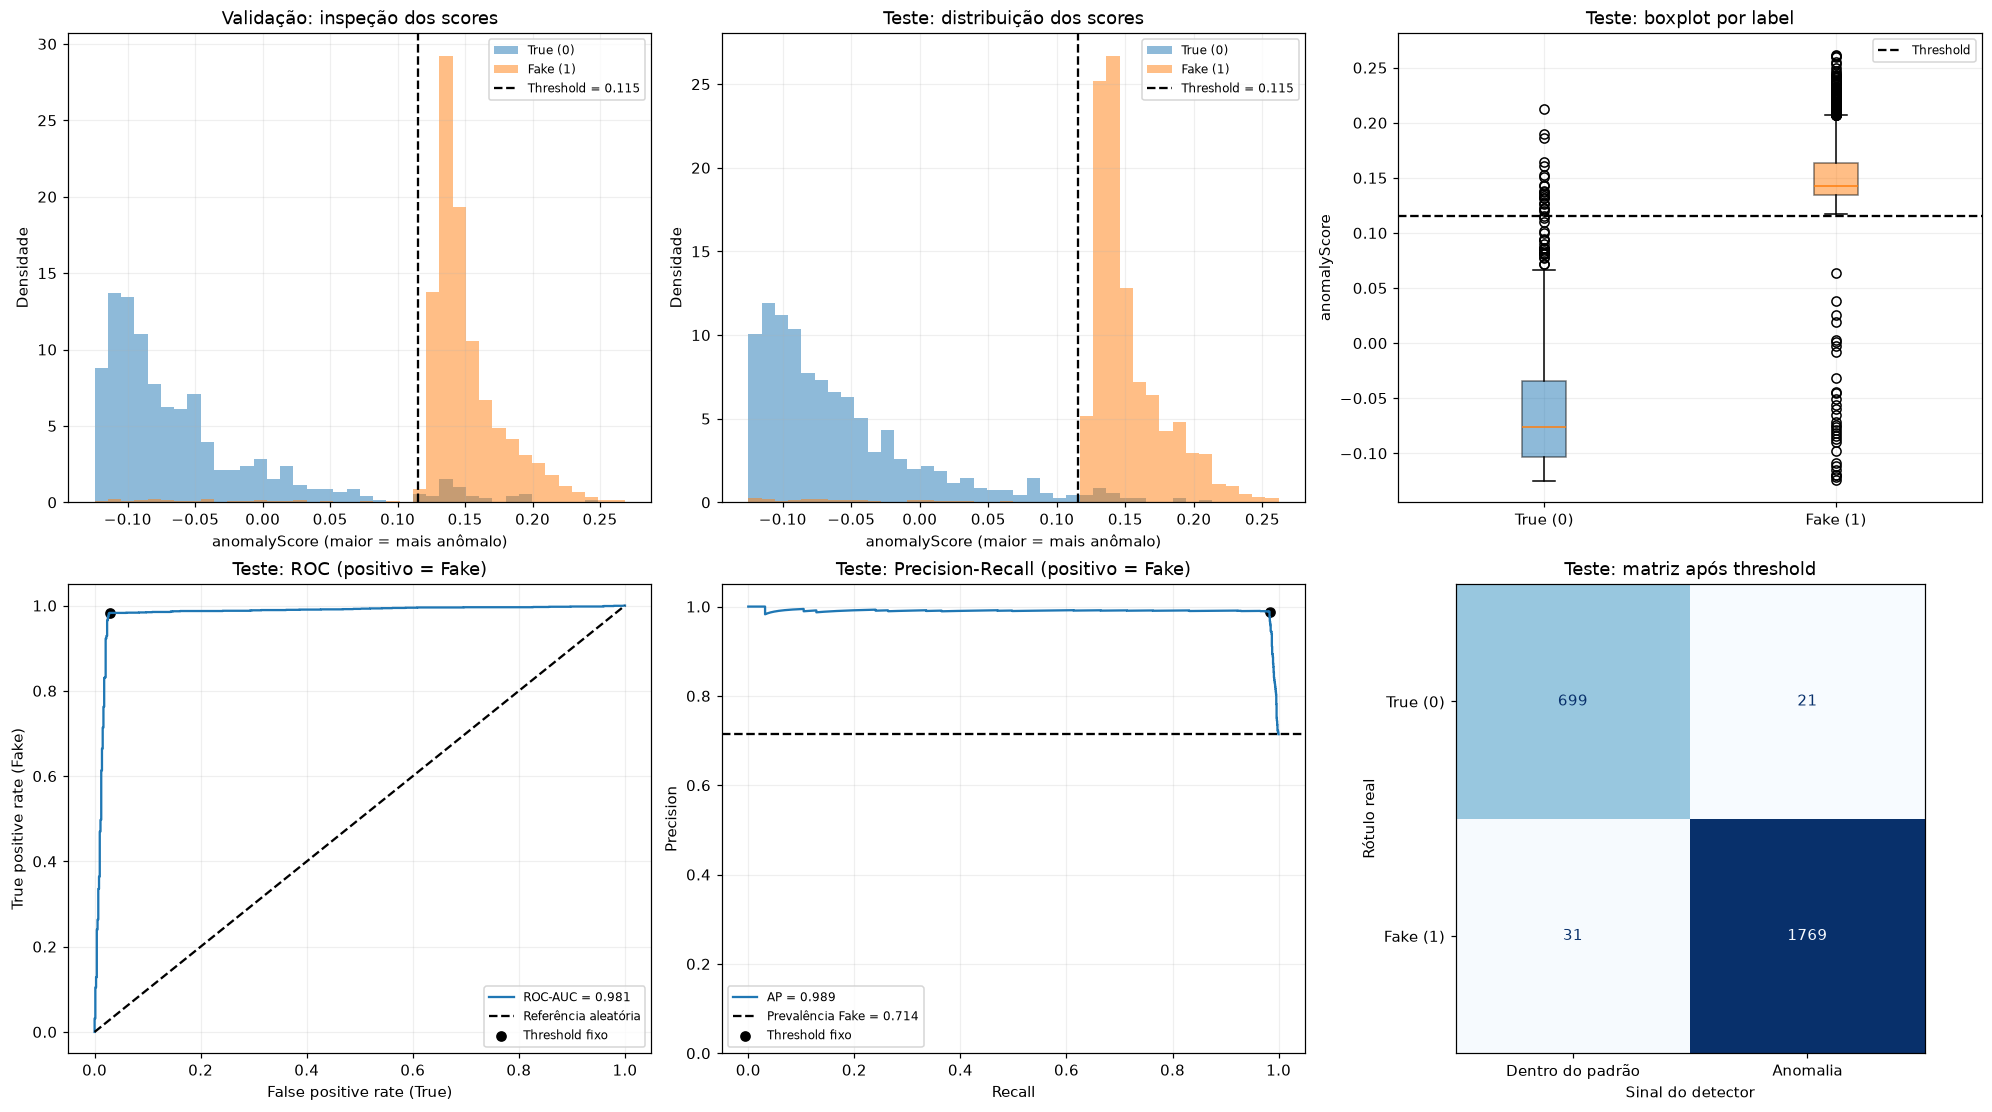

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10), constrained_layout=True)
trueScores = testResultsFrame.loc[testResultsFrame["label"].eq(0), "anomalyScore"]
fakeScores = testResultsFrame.loc[testResultsFrame["label"].eq(1), "anomalyScore"]

for axis, groups, title in [
    (axes[0, 0], [normalValidationScores, fakeValidationScores], "Validação: inspeção dos scores"),
    (axes[0, 1], [trueScores, fakeScores], "Teste: distribuição dos scores"),
]:
    bins = np.histogram_bin_edges(np.concatenate(groups), bins=40)
    for values, name, color in zip(groups, ["True (0)", "Fake (1)"], ["tab:blue", "tab:orange"]):
        axis.hist(values, bins=bins, density=True, alpha=0.5, label=name, color=color)
    axis.axvline(threshold, color="black", linestyle="--", label=f"Threshold = {threshold:.3f}")
    axis.set(title=title, xlabel="anomalyScore (maior = mais anômalo)", ylabel="Densidade")
    axis.legend(fontsize=8)

boxes = axes[0, 2].boxplot([trueScores, fakeScores], patch_artist=True)
for box, color in zip(boxes["boxes"], ["tab:blue", "tab:orange"]):
    box.set_facecolor(color)
    box.set_alpha(0.5)
axes[0, 2].set_xticks([1, 2], ["True (0)", "Fake (1)"])
axes[0, 2].axhline(threshold, color="black", linestyle="--", label="Threshold")
axes[0, 2].set(title="Teste: boxplot por label", ylabel="anomalyScore")
axes[0, 2].legend(fontsize=8)

rocFpr, rocTpr, _ = roc_curve(testLabels, testScores, pos_label=1)
axes[1, 0].plot(rocFpr, rocTpr, label=f"ROC-AUC = {metrics['ROC-AUC']:.3f}")
axes[1, 0].plot([0, 1], [0, 1], "k--", label="Referência aleatória")
axes[1, 0].scatter([falsePositiveRate], [fakeDetectionRate], color="black", label="Threshold fixo")
axes[1, 0].set(title="Teste: ROC (positivo = Fake)", xlabel="False positive rate (True)", ylabel="True positive rate (Fake)")
axes[1, 0].legend(fontsize=8)

prPrecision, prRecall, _ = precision_recall_curve(testLabels, testScores, pos_label=1)
axes[1, 1].plot(prRecall, prPrecision, label=f"AP = {metrics['Average Precision (AP)']:.3f}")
axes[1, 1].axhline(fakePrevalence, color="black", linestyle="--", label=f"Prevalência Fake = {fakePrevalence:.3f}")
axes[1, 1].scatter([metrics["Recall"]], [metrics["Precision"]], color="black", label="Threshold fixo")
axes[1, 1].set(title="Teste: Precision-Recall (positivo = Fake)", xlabel="Recall", ylabel="Precision", ylim=(0, 1.05))
axes[1, 1].legend(fontsize=8)

ConfusionMatrixDisplay(confusionMatrix, display_labels=["True (0)", "Fake (1)"]).plot(
    ax=axes[1, 2], colorbar=False, cmap="Blues", values_format="d",
)
axes[1, 2].set_xticks([0, 1], ["Dentro do padrão", "Anomalia"])
axes[1, 2].set(title="Teste: matriz após threshold", xlabel="Sinal do detector", ylabel="Rótulo real")
axes[1, 2].grid(False)
plt.show()

## 15. Casos extremos

Exemplos exclusivamente do teste: cinco True com maior score, cinco Fake com
maior score e cinco Fake com menor score. Todas as seis features são apresentadas;
não são atribuições causais ou importâncias do Isolation Forest. NaN exibido
na tabela corresponde à feature antes da imputação, preservada para auditoria.

In [22]:
exampleColumns = ["id", "label", "anomalyScore", "isAnomaly"] + anomalyColumns
extremeCases = {
    "5 True com maior anomalyScore": testResultsFrame.loc[testResultsFrame["label"].eq(0)].nlargest(5, "anomalyScore"),
    "5 Fake com maior anomalyScore": testResultsFrame.loc[testResultsFrame["label"].eq(1)].nlargest(5, "anomalyScore"),
    "5 Fake com menor anomalyScore": testResultsFrame.loc[testResultsFrame["label"].eq(1)].nsmallest(5, "anomalyScore"),
}
for title, examples in extremeCases.items():
    display(Markdown(f"**{title}**"))
    display(examples[exampleColumns].reset_index(drop=True))

**5 True com maior anomalyScore**

,id,label,anomalyScore,isAnomaly,tem_autor,typeTokenRatio,linkDensity,punctuationDensity,uppercaseRatio,diversidade
0,262t,0,0.212721,True,0,0.517241,0.0,0.293103,0.000000,0.731707
1,133t,0,0.189983,True,0,0.537313,0.0,0.223881,0.057692,0.692308
2,3298t,0,0.185974,True,1,0.426230,0.0,0.278689,0.000000,0.590909
3,220t,0,0.164661,True,0,0.612903,0.0,0.112903,0.054545,0.690909
4,261t,0,0.160443,True,0,0.649123,0.0,0.087719,0.038462,0.711538


**5 Fake com maior anomalyScore**

,id,label,anomalyScore,isAnomaly,tem_autor,typeTokenRatio,linkDensity,punctuationDensity,uppercaseRatio,diversidade
0,3386,1,0.261826,True,0,0.642857,0.0,0.357143,0.111111,1.000000
1,1834,1,0.261021,True,0,0.540984,0.0,0.360656,0.128205,0.846154
2,2910,1,0.259614,True,0,0.535211,0.0,0.352113,0.130435,0.826087
3,3325,1,0.254704,True,0,0.544118,0.0,0.294118,0.333333,0.770833
4,1005,1,0.252990,True,0,0.445946,0.0,0.283784,0.056604,0.622642


**5 Fake com menor anomalyScore**

,id,label,anomalyScore,isAnomaly,tem_autor,typeTokenRatio,linkDensity,punctuationDensity,uppercaseRatio,diversidade
0,38,1,-0.124589,False,1,0.690909,0.0,0.145455,0.000000,0.808511
1,26,1,-0.121712,False,1,0.706897,0.0,0.137931,0.000000,0.820000
2,1,1,-0.119707,False,1,0.683333,0.0,0.133333,0.019231,0.788462
3,67,1,-0.119610,False,1,0.714286,0.0,0.142857,0.000000,0.833333
4,61,1,-0.115087,False,1,0.689655,0.0,0.120690,0.019608,0.784314


## 16. Conclusão

Resumo calculado a partir desta execução, sem ajuste posterior de modelo ou
threshold. AUC resume ordenação; Recall/FPR resumem o corte escolhido. Nem uma
AUC acima de 0,5 demonstra significância estatística, nem um score alto prova
falsidade. Não estimamos intervalos de confiança nesta V1.

In [23]:
display(Markdown(f"""
Foram treinadas **{len(normalTrainFrame)} notícias True e nenhuma Fake**,
usando até **{CHARACTER_LIMIT} caracteres** e seis features recalculadas.
No teste: **{truePositive}/{len(fakeTestFrame)} Fake detectadas** e
**{falsePositive}/{len(normalTestFrame)} True sinalizadas**.
ROC-AUC: **{metrics['ROC-AUC']:.4f}**; recall **{fakeDetectionRate:.2%}**;
FPR **{falsePositiveRate:.2%}**. Corte: **{threshold:.6f}**, calibrado apenas em True.

num_palavras permanece na extração, mas está fora da matriz de treino.
Correlações por classe estão na seção 8. Caracteres fixos não fixam palavras;
o corte também remove conteúdo e pode cortar frases. Não ajustamos o corte pelo teste.
O controle da seção 17 usa o mesmo extrator sobre o texto completo.
**Anomalia não comprova falsidade.**
"""))


Foram treinadas **2160 notícias True e nenhuma Fake**,
usando até **300 caracteres** e seis features recalculadas.
No teste: **1769/1800 Fake detectadas** e
**21/720 True sinalizadas**.
ROC-AUC: **0.9807**; recall **98.28%**;
FPR **2.92%**. Corte: **0.115188**, calibrado apenas em True.

num_palavras permanece na extração, mas está fora da matriz de treino.
Correlações por classe estão na seção 8. Caracteres fixos não fixam palavras;
o corte também remove conteúdo e pode cortar frases. Não ajustamos o corte pelo teste.
O controle da seção 17 usa o mesmo extrator sobre o texto completo.
**Anomalia não comprova falsidade.**


## 17. Controle de texto completo com o mesmo extrator

Recalculamos as mesmas seis features no texto completo e reutilizamos exatamente
os IDs das partições acima. Cada modelo tem seu corte calibrado na própria
validação True. Esta comparação mantém constantes extrator, features, IDs e
hiperparâmetros. O truncamento muda o conteúdo disponível, portanto não demonstra
isoladamente um efeito causal da quantidade de palavras.

In [24]:
from sklearn.base import clone

fullFeaturesFrame = extractAnomalyFeatures(newsFrame, characterLimit=None).set_index("id", drop=False)
fullTrainFrame = fullFeaturesFrame.loc[normalTrainFrame["id"]]
fullValidationFrame = fullFeaturesFrame.loc[normalValidationFrame["id"]]
fullTestFrame = fullFeaturesFrame.loc[testFrame["id"]]
assert fullTrainFrame["id"].tolist() == normalTrainFrame["id"].tolist()
assert fullTestFrame["label"].tolist() == testLabels.tolist()
fullPipeline = clone(anomalyPipeline)
fitNormalOnly(fullPipeline, fullTrainFrame)
fullValidationScores = calculateAnomalyScore(fullPipeline, fullValidationFrame[anomalyColumns])
fullThreshold = np.quantile(fullValidationScores, 0.95)
fullTestScores = calculateAnomalyScore(fullPipeline, fullTestFrame[anomalyColumns])
fullFlags = fullTestScores >= fullThreshold
lengthComparison = pd.DataFrame([
    {"modelo": "Texto completo: mesmo extrator, seis features", "ROC-AUC": roc_auc_score(testLabels, fullTestScores),
     "Fake detectadas": int(np.sum(fullFlags & (testLabels == 1))), "True sinalizadas": int(np.sum(fullFlags & (testLabels == 0))),
     "corte": float(fullThreshold)},
    {"modelo": f"Primeiros {CHARACTER_LIMIT} caracteres: seis features", "ROC-AUC": metrics["ROC-AUC"],
     "Fake detectadas": int(truePositive), "True sinalizadas": int(falsePositive), "corte": float(threshold)},
])
display(lengthComparison)
display(pd.concat({
    "Completo - treino True": fullTrainFrame[anomalyColumns + ["num_palavras"]].corr()["num_palavras"].drop("num_palavras"),
    "Truncado - treino True": normalTrainFrame[anomalyColumns + ["num_palavras"]].corr()["num_palavras"].drop("num_palavras"),
}, axis=1))
assert "num_palavras" not in fullPipeline.feature_names_in_
assert "num_palavras" not in anomalyPipeline.feature_names_in_
print("Comparação concluída, sem seleção de modelo ou ajuste de corte pelo teste.")

,modelo,ROC-AUC,Fake detectadas,True sinalizadas,corte
0,"Texto completo: mesmo extrator, seis features",0.991937,1771,31,0.082207
1,Primeiros 300 caracteres: seis features,0.980673,1769,21,0.115188


,Completo - treino True,Truncado - treino True
tem_autor,0.043183,0.039037
typeTokenRatio,-0.672996,-0.090910
linkDensity,0.136542,NaN
punctuationDensity,-0.037323,-0.240797
uppercaseRatio,-0.155716,-0.098484
diversidade,-0.692567,-0.280373


Comparação concluída, sem seleção de modelo ou ajuste de corte pelo teste.


## 18. Todas as janelas: cobertura, treino e agregação

Os IDs de treino/validação/teste já estão definidos nos controles acima.
Criamos janelas somente dentro de cada notícia; nunca separamos janelas da
mesma notícia entre treino e teste. O texto é normalizado em NFKC; espaços,
pontuação e fragmento final são mantidos. Cortes podem dividir palavras/frases.

In [25]:
def splitWindows(text, windowSize=300):
    if not isinstance(windowSize, int) or isinstance(windowSize, bool) or windowSize < 1:
        raise ValueError("windowSize deve ser um inteiro positivo.")
    normalized = unicodedata.normalize("NFKC", text).lstrip("\ufeff")
    if not normalized:
        raise ValueError("Texto vazio não permite criar janelas.")
    return [normalized[start:start + windowSize] for start in range(0, len(normalized), windowSize)]

In [26]:
def aggregateWindowScores(scoredWindows):
    values = scoredWindows[["windowCharacters", "windowScore"]].to_numpy(dtype=float)
    if scoredWindows.empty or not np.isfinite(values).all() or (values[:, 0] <= 0).any():
        raise ValueError("Scores finitos e pesos positivos são obrigatórios.")
    weighted = scoredWindows.assign(weightedScore=scoredWindows["windowScore"] * scoredWindows["windowCharacters"])
    result = weighted.groupby("id", sort=False).agg(
        totalWeightedScore=("weightedScore", "sum"), totalCharacters=("windowCharacters", "sum"),
        windowCount=("windowScore", "size"), maximumWindowScore=("windowScore", "max"),
    ).reset_index()
    result["anomalyScore"] = result["totalWeightedScore"] / result["totalCharacters"]
    return result.drop(columns="totalWeightedScore")

In [27]:
def selectTrainingWindows(trainingWindows, seed=42):
    if trainingWindows.empty or not trainingWindows["label"].eq(0).all():
        raise ValueError("Seleção de treino exige exclusivamente notícias True.")
    generator = np.random.default_rng(seed)
    selected = []
    for articleId, group in trainingWindows.groupby("id", sort=False):
        weights = group["windowCharacters"].to_numpy(dtype=float)
        if not np.isfinite(weights).all() or (weights <= 0).any():
            raise ValueError("Comprimentos das janelas devem ser positivos e finitos.")
        position = generator.choice(len(group), p=weights / weights.sum())
        selected.append(group.iloc[[position]])
    return pd.concat(selected, ignore_index=True)

In [28]:
def makeWindowFrame(articles, windowSize=300):
    if articles.empty or not articles["id"].is_unique:
        raise ValueError("São necessárias notícias com IDs únicos.")
    records = []
    for row in articles[["id", "label", "tem_autor", "text"]].itertuples(index=False):
        for windowIndex, chunk in enumerate(splitWindows(row.text, windowSize)):
            records.append({"id": row.id, "label": row.label, "tem_autor": row.tem_autor,
                            "text": chunk, "num_palavras": np.nan,
                            "windowIndex": windowIndex, "windowCharacters": len(chunk)})
    return extractAnomalyFeatures(pd.DataFrame(records), characterLimit=None)


def scoreWindowArticles(pipeline, windows, articles):
    if not articles["id"].is_unique or set(windows["id"]) != set(articles["id"]):
        raise ValueError("Janelas e notícias precisam cobrir os mesmos IDs únicos.")
    scored = windows[["id", "windowIndex", "windowCharacters", "num_palavras", "text"]].copy()
    scored["windowScore"] = calculateAnomalyScore(pipeline, windows[anomalyColumns])
    combined = aggregateWindowScores(scored)
    results = articles[["id", "label"]].merge(combined, on="id", validate="one_to_one", sort=False)
    return results, scored

In [29]:
from sklearn.base import clone

WINDOW_SIZE = 300
rawById = newsFrame.set_index("id", drop=False)
windowPartitions = {}
for name, frame in partitions.items():
    windowPartitions[name] = makeWindowFrame(rawById.loc[frame["id"]], WINDOW_SIZE)
    assert set(windowPartitions[name]["id"]) == set(frame["id"])
for (leftName, left), (rightName, right) in combinations(windowPartitions.items(), 2):
    assert set(left["id"]).isdisjoint(right["id"])

selectedTrainingWindows = selectTrainingWindows(windowPartitions["normalTrain"], seed=RANDOM_STATE)
assert len(selectedTrainingWindows) == len(normalTrainFrame) == 2160
assert selectedTrainingWindows["id"].is_unique
assert set(selectedTrainingWindows["id"]) == set(normalTrainFrame["id"])
windowPipeline = clone(anomalyPipeline)
fitNormalOnly(windowPipeline, selectedTrainingWindows)
assert "num_palavras" not in windowPipeline.feature_names_in_

windowValidationResults, windowValidationDetails = scoreWindowArticles(
    windowPipeline, windowPartitions["normalValidation"], normalValidationFrame,
)
windowThreshold = float(np.quantile(windowValidationResults["anomalyScore"], 0.95))
windowTestFrame = pd.concat([windowPartitions["normalTest"], windowPartitions["fakeTest"]], ignore_index=True)
windowTestResults, windowTestDetails = scoreWindowArticles(windowPipeline, windowTestFrame, testFrame)
windowTestResults["isAnomaly"] = windowTestResults["anomalyScore"] >= windowThreshold
assert windowTestResults["id"].tolist() == testFrame["id"].tolist()
assert windowTestResults["label"].tolist() == testLabels.tolist()
assert len(windowTestResults) == 2520

windowCounts = pd.DataFrame([
    {"partição": name, "notícias": frame["id"].nunique(), "trechos disponíveis": len(frame),
     "trechos usados em fit": len(selectedTrainingWindows) if name == "normalTrain" else 0}
    for name, frame in windowPartitions.items()
])
display(windowCounts)
print("Corte sobre notícias True de validação:", windowThreshold)
print("FPR de validação:", float((windowValidationResults["anomalyScore"] >= windowThreshold).mean()))

,partição,notícias,trechos disponíveis,trechos usados em fit
0,normalTrain,2160,48907,2160
1,normalValidation,720,16530,0
2,normalTest,720,16471,0
3,fakeValidation,1800,7740,0
4,fakeTest,1800,7574,0


Corte sobre notícias True de validação: -0.025124678789214944
FPR de validação: 0.05


## 19. Comparação no mesmo teste por notícia

Cada linha abaixo foi reexecutada neste notebook com as mesmas seis features,
os mesmos IDs, seed e hiperparâmetros. O modelo por janelas recebe um trecho
sorteado por notícia no fit, enquanto o controle truncado usa sempre a abertura.
Os cortes são calibrados separadamente em scores de notícias True de validação.

num_palavras não entra diretamente em nenhum modelo. Autor permanece em todos.
ROC-AUC mede ordenação; acurácia e recall dependem do corte e da prevalência.

,modelo,Fake detectadas,Fake perdidas,True sinalizadas,True sem alerta,acurácia,recall,FPR,precision,F1,ROC-AUC,AP,corte
0,Texto completo - seis features,1771,29,31,689,0.976190,0.983889,0.043056,0.982797,0.983343,0.991937,0.993553,0.082207
1,Primeiros 300 caracteres - seis features,1769,31,21,699,0.979365,0.982778,0.029167,0.988268,0.985515,0.980673,0.988672,0.115188
2,Todos os trechos - média ponderada,1771,29,22,698,0.979762,0.983889,0.030556,0.987730,0.985806,0.984725,0.989020,-0.025125


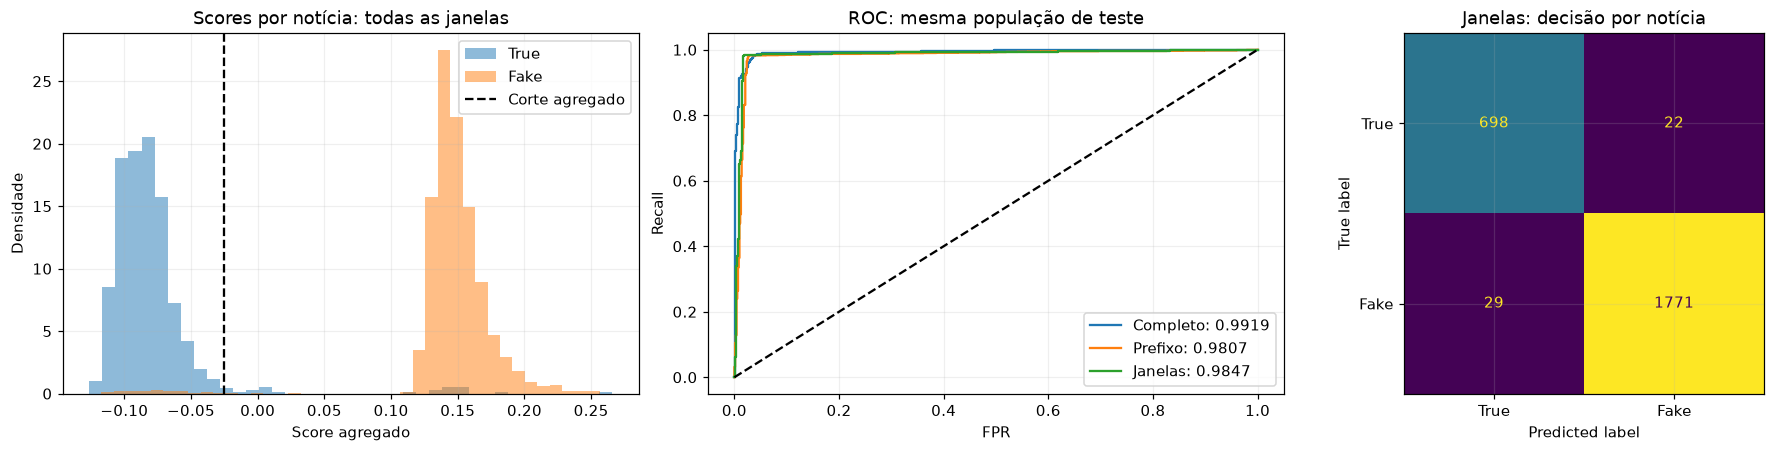

,,anomalyScore,num_palavras,windowCount
label,,,,
0,anomalyScore,1.0,-0.097447,-0.095369
1,anomalyScore,1.0,-0.272463,-0.267812


Correlação descritiva por classe, sem ajustar a agregação ou o corte com estes resultados.


In [30]:
def summarizeNewsScores(name, labels, scores, cutoff):
    labels, scores = np.asarray(labels), np.asarray(scores)
    flags = scores >= cutoff
    tn, fp, fn, tp = confusion_matrix(labels, flags, labels=[0, 1]).ravel()
    return {"modelo": name, "Fake detectadas": int(tp), "Fake perdidas": int(fn),
            "True sinalizadas": int(fp), "True sem alerta": int(tn),
            "acurácia": float((tp + tn) / len(labels)), "recall": float(tp / (tp + fn)),
            "FPR": float(fp / (fp + tn)), "precision": float(tp / (tp + fp)) if tp + fp else 0.0,
            "F1": float(2 * tp / (2 * tp + fp + fn)), "ROC-AUC": float(roc_auc_score(labels, scores)),
            "AP": float(average_precision_score(labels, scores)), "corte": float(cutoff)}

windowComparison = pd.DataFrame([
    summarizeNewsScores("Texto completo - seis features", testLabels, fullTestScores, fullThreshold),
    summarizeNewsScores("Primeiros 300 caracteres - seis features", testLabels, testScores, threshold),
    summarizeNewsScores("Todos os trechos - média ponderada", testLabels, windowTestResults["anomalyScore"], windowThreshold),
])
display(windowComparison)

windowConfusion = confusion_matrix(testLabels, windowTestResults["isAnomaly"], labels=[0, 1])
windowFig, windowAxes = plt.subplots(1, 3, figsize=(17, 4), constrained_layout=True)
for label, group in windowTestResults.groupby("label"):
    windowAxes[0].hist(group["anomalyScore"], bins=40, density=True, alpha=0.5, label=labelNames[label])
windowAxes[0].axvline(windowThreshold, color="black", linestyle="--", label="Corte agregado")
windowAxes[0].set(title="Scores por notícia: todas as janelas", xlabel="Score agregado", ylabel="Densidade")
windowAxes[0].legend()
for name, scores in [("Completo", fullTestScores), ("Prefixo", testScores), ("Janelas", windowTestResults["anomalyScore"])]:
    fpr, tpr, _ = roc_curve(testLabels, scores)
    windowAxes[1].plot(fpr, tpr, label=f"{name}: {roc_auc_score(testLabels, scores):.4f}")
windowAxes[1].plot([0, 1], [0, 1], "k--")
windowAxes[1].set(title="ROC: mesma população de teste", xlabel="FPR", ylabel="Recall")
windowAxes[1].legend()
ConfusionMatrixDisplay(windowConfusion, display_labels=["True", "Fake"]).plot(ax=windowAxes[2], colorbar=False, values_format="d")
windowAxes[2].set_title("Janelas: decisão por notícia")
plt.show()

windowAudit = windowTestResults.merge(rawById[["id", "num_palavras"]].reset_index(drop=True), on="id", validate="one_to_one")
display(windowAudit.groupby("label")[["anomalyScore", "num_palavras", "windowCount"]].corr().loc[(slice(None), "anomalyScore"), :])
print("Correlação descritiva por classe, sem ajustar a agregação ou o corte com estes resultados.")

## 20. Resultado e limites

Todos os trechos contribuem para o score final, mas suas palavras são representadas
apenas por seis medidas; não há compreensão semântica nem verificação factual.
Scores máximos ficam disponíveis para auditoria e não alteram a decisão principal.
Uma média pode diluir um trecho isolado suspeito. Também permanecem efeitos de
fonte/autoria, tema, tamanho, posição e pares temáticos entre partições.
Não usamos os resultados para escolher outro agregador, semente ou cutoff.

In [31]:
windowResult = windowComparison.iloc[-1]
display(Markdown(f"""
Foram treinadas **2160 notícias True e nenhuma Fake**, com um trecho sorteado por notícia.
Na validação e no teste, todas as janelas contribuem para a média ponderada por caracteres.
O teste possui **720 True e 1800 Fake**.

**Todos os trechos:** {int(windowResult['Fake detectadas'])}/1800 Fake detectadas;
{int(windowResult['True sinalizadas'])}/720 True sinalizadas por engano.
Acurácia **{windowResult['acurácia']:.2%}**; recall **{windowResult['recall']:.2%}**;
FPR **{windowResult['FPR']:.2%}**; ROC-AUC **{windowResult['ROC-AUC']:.4f}**.

Este resultado avalia combinação de medidas de escrita neste split do corpus.
**Anomalia não comprova falsidade.** A mudança inclui amostragem de treino e agregação,
não somente cobertura do texto; não demonstra superioridade estatística nem generalização.
"""))


Foram treinadas **2160 notícias True e nenhuma Fake**, com um trecho sorteado por notícia.
Na validação e no teste, todas as janelas contribuem para a média ponderada por caracteres.
O teste possui **720 True e 1800 Fake**.

**Todos os trechos:** 1771/1800 Fake detectadas;
22/720 True sinalizadas por engano.
Acurácia **97.98%**; recall **98.39%**;
FPR **3.06%**; ROC-AUC **0.9847**.

Este resultado avalia combinação de medidas de escrita neste split do corpus.
**Anomalia não comprova falsidade.** A mudança inclui amostragem de treino e agregação,
não somente cobertura do texto; não demonstra superioridade estatística nem generalização.
